# Notebook 3: The Watchlist 

This notebook turns the XGBoost out-of-fold probabilities into one of the project's  deliverables: a ranked watchlist of undesignated planning areas that most resemble Milieuschutz-designated ones. 

Working from the out-of-fold scores keeps every ranking honest, since each area was scored by a model that never saw its own district. 
After restricting to undesignated areas (y_true = 0), the local spread and the distribution of scores are inspected to find a defensible cutoff point, which is then confirmed by the Cleanlab and regression validations. The shortlist is then mapped across Berlin.

As throughout all notebooks of Module 2, the score expresses similarity to the existing designation pattern, not an objective probability of displacement. The undesignated areas surfacing near the top are precisely the early-warning candidates the platform is built to find.


## Load Libraries and Data 

In [1]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch


In [2]:
#load the XGBoost OOF probabilities set 
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#load dataset_0 for readable identifiers (plr_name, bez)
meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

#zero-pad plr_id consistently (same convention as NB1/NB2)
for d in (xgb_oof, meta):   
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#build the working table: XGBoost oof_prob + labels + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#sanity 
assert df["plr_name"].notna().all(), "some PLR did not get a name/district — check the merge"
assert len(df) == len(xgb_oof), "merge changed row count — duplicate plr_id?"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | "
      f"{int((df['y_true']==0).sum())} undesignated")

527 PLR | 109 designated | 418 undesignated


### The out-of-fold Probabilities: Inspection

To turn the continuous ranking into a finite shortlist, the out-of-fold probabilities of the undesignated areas are inspected for a natural break. The scores are first mapped across Berlin to see where the high-probability areas sit spatially, then their distribution is compared against the designated areas to locate the high-scoring tail. Finally, the ranked list of undesignated areas is examined directly, to find the point where the probabilities step down and a defensible cutoff can be placed.


In [3]:
#plot the probabilities on the map of Berlin 
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

print("Spalten:", gdf.columns.tolist())
print("CRS:", gdf.crs)
print("Zeilen:", len(gdf))
print(gdf.drop(columns="geometry").head(3).to_string())

Spalten: ['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
CRS: EPSG:25833
Zeilen: 542
                        id    plr_id           plr_name  bzr_id        bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id stadtraum_name       stand
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   Innere Stadt  01.01.2021
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   Innere Stadt  01.12.2021
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   Innere Stadt  01.12.2021


In [4]:
#Merge model output onto PLR geometries; milieu_anteil pulled in SEPARATELY (interpretation only, never a feature)
#milieu_anteil taken from target_milieuschutz.csv — kept out of df on purpose

milieu = (pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
            .assign(plr_id=lambda d: d["plr_id"].astype(str).str.zfill(8)))

plot_geo = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(milieu[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 1: Plot resemblance list for all with protected areas <50%
undes = (plot_geo["y_true"] == 0)

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch = plot_geo["oof_prob"].isna().sum()
print(f"{len(plot_geo)} geometries | {n_nomatch} without a model row (dropped/uninhabited PLR)")


542 geometries | 15 without a model row (dropped/uninhabited PLR)


gezeichnete PLR: 542 | davon mit oof_prob: 527


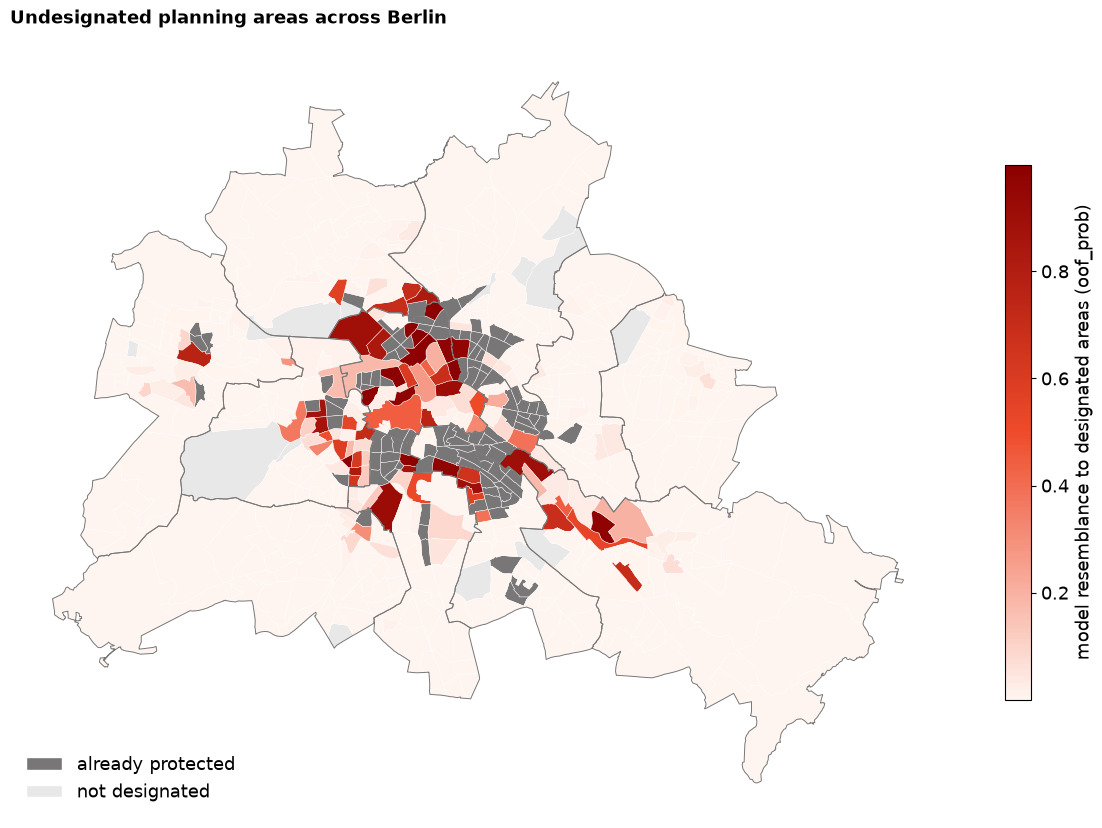

In [5]:


#data check: no values PLRs? 
print("gezeichnete PLR:", len(plot_geo),
      "| davon mit oof_prob:", plot_geo["oof_prob"].notna().sum())

red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])

fig, ax = plt.subplots(figsize=(12, 11))

#Plot layer 1: all PLRS grey 
plot_geo.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#Plot layer 2: designated PLRs in darker grey 
plot_geo[plot_geo["y_true"] == 1].plot(
    ax=ax, color="#787676", edgecolor="white", linewidth=0.3
)

#Plot layer 3: undesignated PLR, coloured by similarity score 
plot_geo[undes].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, column="oof_prob",
    legend_kwds={
        "label": "model resemblance to designated areas (oof_prob)",
        "shrink": 0.5,
    },
)

#boundaries of districts 
gdf.dissolve("bez").boundary.plot(ax=ax, color="#787777", linewidth=0.7)

#Colorbar-Schrift auf 13 (Label + Ticks) 
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("model resemblance to designated areas (oof_prob)", fontsize=13)
cbar_ax.tick_params(labelsize=13)

#catergorical legend on the map 
handles = [
    Patch(facecolor="#787676", edgecolor="white", label="already protected"),
    Patch(facecolor="#e8e8e8", edgecolor="white", label="not designated"),
]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=13)

ax.set_title("Undesignated planning areas across Berlin",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_oofprob_Berlin.png", dpi=200, bbox_inches="tight")
plt.show()

## Map of out-of-fold probabilities in Berlin 

The resemblance surface shades every unprotected planning area by how strongly the model rates it as designation-like, and the high-scoring areas cluster tightly in the inner-city ring, wrapping directly around the grey already-protected areas mainly in Mitte, but also inside the ring in Tempelhof-Schöneberg, Charlottenburg-Wilmersdorf and northern Neukölln. 

The one interesting departure from that pattern is a red arm reaching south-east out of the ring into Treptow-Köpenick, led by the planning areas Griechischer Park and Alt-Treptow: the clearest signal of designation-like conditions beyond the districts where protection has so far concentrated. 

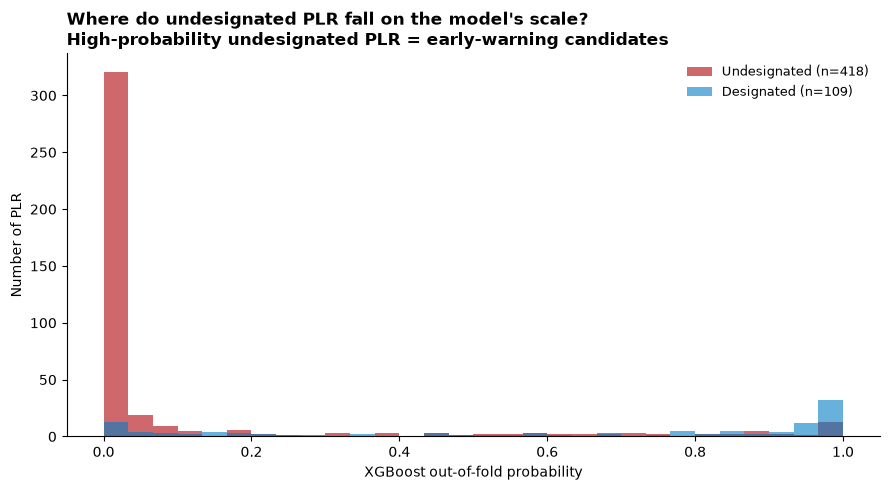

       plr_id                     plr_name                              bez  oof_prob
1    01401044                   Uferstraße                       01 - Mitte  0.999109
2    01300731                Koloniestraße                       01 - Mitte  0.997601
3    01100416                  Arkonaplatz                       01 - Mitte  0.995976
4    07100206           Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5    01200623                  Stephankiez                       01 - Mitte  0.986148
6    01401049                  Schulstraße                       01 - Mitte  0.985959
7    04501147            Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600
8    01300836        Humboldthain Nordwest                       01 - Mitte  0.984006
9    01200522           Elberfelder Straße                       01 - Mitte  0.983263
10   01200628            Lüneburger Straße                       01 - Mitte  0.979387
11   09200511            Griechischer Park            

In [6]:
#The distribution of XGBoost oof_prob, split by actual designation status
#Goal: where do undesignated PLR sit? Is there a natural cutoff for the watchlist that can be used?
desig   = df.loc[df["y_true"] == 1, "oof_prob"]
undesig = df.loc[df["y_true"] == 0, "oof_prob"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 31)
ax.hist(undesig, bins=bins, alpha=0.6, color="#AE030C", label=f"Undesignated (n={len(undesig)})")
ax.hist(desig,   bins=bins, alpha=0.6, color="#027DC5", label=f"Designated (n={len(desig)})")
ax.set_xlabel("XGBoost out-of-fold probability", fontsize=10)
ax.set_ylabel("Number of PLR", fontsize=10)
ax.set_title("Where do undesignated PLR fall on the model's scale?\n"
             "High-probability undesignated PLR = early-warning candidates",
             fontsize=12, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#eyeball the top undesignated PLR to see where probabilities start dropping
top_undesig = (df[df["y_true"] == 0]
               .sort_values("oof_prob", ascending=False)
               [["plr_id", "plr_name", "bez", "oof_prob"]]
               .head(100)
               .reset_index(drop=True))
top_undesig.index = top_undesig.index + 1                    
print(top_undesig.to_string())

### The Watchlist 

The out-of-fold probabilities are turned into an actionable shortlist by keeping only undesignated planning areas (milieu_anteil below the majority threshold) and ranking them by how strongly the model rates them as designation-like. 

The scores fall off gradually, but a visible step appears after the 25th-ranked area, where the out-of-fold probability drops from 0.824 to 0.767: the largest gap in the high-scoring range. This step provides a natural, if pragmatic, cutoff: the 25 areas above it are those the model scores most like already-designated areas, and the drop marks where that resemblance begins to thin out.

We fix the watchlist at these 25. The length is confirmed by two independent checks — Cleanlab (NB5) flags all 25 as label-inconsistent (100%), and the regression cross-check (NB6) recovers 20 of them from a different target. While the cut itself is a deliberate choice, it is one both validations support.


In [7]:
#export the watchlist 
#Cutoff N=25, chosen at the visible probability drop (0.824 -> 0.767 after rank 25)

N_LIST = 25

watchlist = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_LIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist.index = watchlist.index + 1
watchlist.index.name = "rank"

cutoff_in  = watchlist["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)["oof_prob"].iloc[N_LIST])
print(f"Watchlist: {N_LIST} undesignated PLR (pure oof_prob ranking)")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"District distribution:\n{watchlist['bez'].value_counts().to_string()}")
print()
print(watchlist.to_string())

#export the watchlist (to be validated by cleanlab in NB5)
watchlist_out = watchlist.reset_index()
watchlist_out.to_csv("../../models/M2_watchlist.csv", index=False)
print(f"\nexported {len(watchlist_out)} PLR -> M2_watchlist.csv")



Watchlist: 25 undesignated PLR (pure oof_prob ranking)
Cutoff: last included oof_prob = 0.824 | first excluded = 0.767
District distribution:
bez
01 - Mitte                         12
04 - Charlottenburg-Wilmersdorf     4
07 - Tempelhof-Schöneberg           3
09 - Treptow-Köpenick               2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
08 - Neukölln                       1
12 - Reinickendorf                  1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     01200623             Stephankiez                   

gezeichnete PLR: 542 | davon mit oof_prob: 527


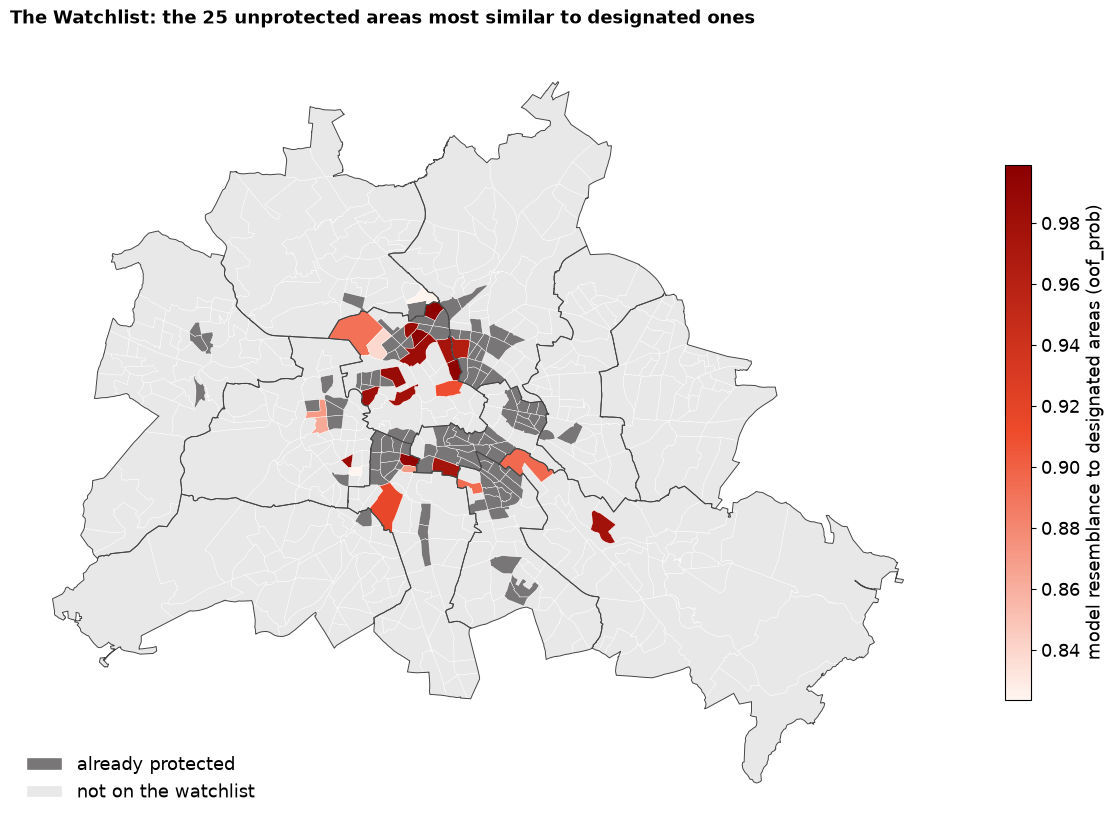

In [ ]:

#data check 
print("gezeichnete PLR:", len(plot_geo),
      "| davon mit oof_prob:", plot_geo["oof_prob"].notna().sum())

red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])
wl_ids = set(watchlist["plr_id"])
is_wl  = plot_geo["plr_id"].isin(wl_ids)

fig, ax = plt.subplots(figsize=(12, 11))

#same layer 1 as above 
plot_geo.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#same layer 2 as above 
plot_geo[plot_geo["y_true"] == 1].plot(
    ax=ax, color="#787676", edgecolor="white", linewidth=0.3
)

#plot layer 3: only unprotected PLRs on watchlist 
plot_geo[is_wl].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, column="oof_prob",
    legend_kwds={
        "label": "model resemblance to designated areas (oof_prob)",
        "shrink": 0.5,
    },
)

# Bezirksgrenzen
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

# Colorbar-Schrift auf 13 (Label + Ticks) 
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("model resemblance to designated areas (oof_prob)", fontsize=13)
cbar_ax.tick_params(labelsize=13)

#categorical legend on the map  
handles = [
    Patch(facecolor="#787676", edgecolor="white", label="already protected"),
    Patch(facecolor="#e8e8e8", edgecolor="white", label="not on the watchlist"),
]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=13)

ax.set_title("The Watchlist: the 25 unprotected areas most similar to designated ones",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_watchlist_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## Result: Map of the Watchlist 

Mapped across Berlin, the 25 watchlist areas cluster tightly in the inner-city ring, wrapping around the grey already-protected areas — densest in Mitte, with further areas in Tempelhof-Schöneberg, Charlottenburg-Wilmersdorf and northern Neukölln. This spatial coherence is a plausibility check in itself: the model was never given location, yet the areas it flags reproduce the geography of existing Milieuschutz, sitting in the same inner-ring fabric as the designated ones.

Two of the 25 stand out for their location: Griechischer Park and Alt-Treptow reach south-east into Treptow-Köpenick, out of the inner ring — the clearest signal of designation-like conditions beyond the districts where protection has so far concentrated.

Read as early warning rather than diagnosis, the map does not measure gentrification directly; it flags unprotected areas whose features resemble those already found worthy of protection. Where designation elsewhere responded to displacement pressure, these look-alikes plausibly face comparable conditions — marking them as areas that warrant examination before that pressure is formally recognised.

## Caveats - and how to handle them 

Three caveats frame how this watchlist should be read:

First and most important, the model learns similarity to already-designated areas, not gentrification or displacement directly. A high score means an area structurally resembles the neighbourhoods districts have chosen to protect, which is an informative signal but not a measurement of displacement pressure itself. The unprotected look-alikes it surfaces (statistically the model's "false positives") are therefore the intended output, not errors: they are exactly the areas that share the designation fingerprint without yet carrying protection.

Second, the length of the list is a deliberate cut, not a natural boundary. The 25 sits at the largest visible gap in the ranking (0.824 → 0.767), but the scores decline continuously, so areas just below the cut differ only marginally from those just above it. A longer list would have been defensible: Cleanlab flags designation-like signal continuing past rank 25 but we chose the tighter, higher-confidence shortlist, prioritising precision at the top of the ranking over broader coverage. The cut is a choice, and both validation notebooks (NB5, NB6) confirm the 25 rather than override them.

Third, the watchlist includes areas from the weak cross-validation fold (Charlottenburg-Wilmersdorf), where the model has fewer positive examples to learn from and its probabilities are correspondingly less reliable. The higher-ranked areas there (e.g. Leon-Jessel-Platz, Schloßstraße) remain robust, but the lower-scored ones should be read with that caveat in mind. 

These findings are cross-checked in two independent ways: Cleanlab (NB5) audits the labels themselves, and a regression (NB6) re-derives the ranking from the continuous milieu_anteil rather than the binary label.

In [9]:
#Module2 final dataset 
#copy df from cell 3 
backup = df.copy()

# Watchlist-Flag aus der bereits exportierten Deliverable-Liste (single source of truth)
wl = pd.read_csv("../../models/M2_watchlist.csv", dtype={"plr_id": str})
wl["plr_id"] = wl["plr_id"].str.zfill(8)
backup["on_watchlist"] = backup["plr_id"].isin(set(wl["plr_id"]))

backup = (backup[["plr_id", "plr_name", "bez", "y_true", "oof_prob", "on_watchlist"]]
          .sort_values("oof_prob", ascending=False)
          .reset_index(drop=True))

# sanity (prose == computation)
assert backup["oof_prob"].isna().sum() == 0, "oof_prob fehlt"
assert backup["on_watchlist"].sum() == len(wl), \
    f"Flag ({backup['on_watchlist'].sum()}) != Watchlist-Länge ({len(wl)})"
assert (backup.loc[backup["on_watchlist"], "y_true"] == 0).all(), \
    "Watchlist darf nur undesignierte PLR enthalten"

print(f"{len(backup)} PLR | {int(backup['y_true'].sum())} designated | "
      f"on_watchlist: {int(backup['on_watchlist'].sum())}")

backup.to_csv("../../models/df_backup.csv", index=False)
print("exported -> models/df_backup.csv")

527 PLR | 109 designated | on_watchlist: 25
exported -> models/df_backup.csv


## Why 12/25 in Mitte? 

Mitte makes up 9% of all planning areas and 16% of the designated ones — already over-represented — but 48% of the watchlist. Part of that follows the existing pattern: the model learns the inner-city, pre-1919 profile that Berlin has already chosen to protect, and Mitte has a lot of it. But the jump to 48% is larger than the 16% designation share alone explains, which means Mitte holds many still-unprotected areas that closely resemble the protected ones — exactly the look-alikes the tool is built to surface. The flip side, and a real limitation, is that such a strong concentration in one district may mean the model keys on a narrow structural profile and under-weights pressure that looks different elsewhere.

In [10]:
mitte = df["bez"].str.contains("Mitte")
print("Mitte an allen PLR:", f"{mitte.mean():.0%}")
b = pd.read_csv("../../models/df_backup.csv")
print("Mitte an designierten:", f"{b.loc[b['y_true']==1,'bez'].str.contains('Mitte').mean():.0%}")

Mitte an allen PLR: 9%
Mitte an designierten: 16%


## Checking Reliability Flags in rent dimension for the Watchlist PLRs

In [11]:
df_path = "../../data/final_datasets/df_clusters_milieuschutz.csv"   
re_path = "../../data/real_estate/final_variables/re_eda_input.csv"               

# --- laden + Key vereinheitlichen (beide auf 8-stellige plr_id) ---
df_r = pd.read_csv(df_path)
re = pd.read_csv(re_path)
df_r["plr_id"] = df_r["plr_id"].astype(str).str.zfill(8)
re["plr_id"] = re["plr_id"].astype(str).str.zfill(8)

# --- cs = re_eda (Flags + Features) + Watchlist-Info aus dem Delivery-df ---
cs = re.merge(df_r[["plr_id", "on_watchlist", "oof_prob"]], on="plr_id", how="right")
print("gematcht:", cs["miete_niveau"].notna().sum(), "von", len(cs))   

gematcht: 527 von 527


In [12]:
# --- sanity (prose == computation) ---
assert cs["on_watchlist"].sum() == 25, f"erwartet 25, ist {cs['on_watchlist'].sum()}"
assert cs["oof_prob"].isna().sum() == 0, "oof_prob fehlt"

# --- Polaritäts-Check der Flags (Kodierung verifizieren) ---
for f in ["miete_unsicher", "cov_wohnen_2025", "var5_brw_wohnen_trend_outlier", "baualter_unsicher"]:
    print(f, "->", cs[f].value_counts(dropna=False).to_dict())

miete_unsicher -> {0: 400, 1: 127}
cov_wohnen_2025 -> {1.0: 68, 0.9999999999999998: 4, 0.468166714724585: 1, 0.0340101749522261: 1, 0.9982090524712944: 1, 0.9999945620831148: 1, 0.1507894727570859: 1, 0.0012198235221886: 1, 0.2194912336754478: 1, 0.2983109699161757: 1, 0.7783054841610879: 1, 0.1278014934942704: 1, 0.7831075849377218: 1, 0.5658881694952577: 1, 0.5290886030190821: 1, 0.2668311982227488: 1, 0.9044986545570786: 1, 0.0777482986066001: 1, 0.8918916853054013: 1, 0.9997834562525536: 1, 0.9704755270383064: 1, 0.8813971452634842: 1, 0.8205162207326334: 1, 0.9959685426216628: 1, 0.5314081084578247: 1, 0.9446505360370044: 1, 0.4879553695147234: 1, 0.9999515273352728: 1, 0.3616702341624486: 1, 0.9481733257327608: 1, 0.7358472744624157: 1, 0.723626927535017: 1, 0.9456296456596184: 1, 0.8430631642927654: 1, 0.4435540199549748: 1, 0.6244002049461177: 1, 0.2055139083835472: 1, 0.3959259938817097: 1, 0.6290766503542101: 1, 0.7162910287825525: 1, 0.9831174199215144: 1, 0.985831110115836:

In [13]:
#Flag definition
flag_specs = [
    ("miete_niveau",           cs["miete_unsicher"].fillna(0) == 1,                 "fallzahl < 21"),
    ("miete_trend",            cs["miete_unsicher"].fillna(0) == 1,                 "fallzahl < 21"),
    ("var5_brw_wohnen_niveau", cs["cov_wohnen_2025"].fillna(0) < 0.5,               "cov_wohnen < 0.5"),
    ("var5_brw_wohnen_trend",  cs["var5_brw_wohnen_trend_outlier"].fillna(0) == 1,  "trend outlier"),
    ("anteil_vor_1919",        cs["baualter_unsicher"].fillna(0) == 1,              "< 50 Wohnungen"),
    ("dichte_all",             cs["baualter_unsicher"].fillna(0) == 1,              "< 50 Wohnungen"),
]

watch_mask = cs["on_watchlist"] == True
n_watch, n_total = int(watch_mask.sum()), len(cs)

In [14]:
#view 1: pro Feature-Flag, Watchlist vs. Baseline ---
rows = []
for feat, mask, reason in flag_specs:
    w = int((mask & watch_mask).sum())
    b = int(mask.sum())
    rows.append({
        "feature":   feat,
        "flag":      reason,
        "watchlist": f"{w}/{n_watch} = {w/n_watch:.0%}",
        "baseline":  f"{b}/{n_total} = {b/n_total:.0%}",
    })
print(pd.DataFrame(rows).to_string(index=False))

               feature             flag  watchlist      baseline
          miete_niveau    fallzahl < 21 4/25 = 16% 127/527 = 24%
           miete_trend    fallzahl < 21 4/25 = 16% 127/527 = 24%
var5_brw_wohnen_niveau cov_wohnen < 0.5 7/25 = 28% 133/527 = 25%
 var5_brw_wohnen_trend    trend outlier  0/25 = 0%    0/527 = 0%
       anteil_vor_1919   < 50 Wohnungen  0/25 = 0%    0/527 = 0%
            dichte_all   < 50 Wohnungen  0/25 = 0%    0/527 = 0%


In [15]:
#view 2: which of the Watchlist-PLRs have flag features? 
feat_cols = [feat for feat, _, _ in flag_specs]
fm = pd.DataFrame({feat: mask.values for feat, mask, _ in flag_specs}, index=cs.index)
fm["n_flagged_features"] = fm[feat_cols].sum(axis=1)
fm["plr_name"] = cs["plr_name"].values
fm["oof_prob"] = cs["oof_prob"].values

watch_fm = (fm[watch_mask.values]
            .sort_values(["n_flagged_features", "oof_prob"], ascending=[False, False]))
print(watch_fm[["plr_name", "oof_prob", "n_flagged_features", *feat_cols]].to_string(index=False))

              plr_name  oof_prob  n_flagged_features  miete_niveau  miete_trend  var5_brw_wohnen_niveau  var5_brw_wohnen_trend  anteil_vor_1919  dichte_all
     Lüneburger Straße  0.979387                   3          True         True                    True                  False            False       False
     Leon-Jessel-Platz  0.984600                   2          True         True                   False                  False            False       False
  Hohenfriedbergstraße  0.871418                   2          True         True                   False                  False            False       False
           Wilhelmsaue  0.823657                   2          True         True                   False                  False            False       False
             Falkplatz  0.963523                   1         False        False                    True                  False            False       False
          Grazer Platz  0.916001                   1         Fal

In [16]:
b = int((cs["cov_wohnen_2025"].fillna(0) < 0.5).sum())
print(f"BRW cov<0.5 Baseline: {b}/{len(cs)} = {b/len(cs):.0%}")

BRW cov<0.5 Baseline: 133/527 = 25%


In [17]:
check = pd.read_csv(
    "../../data/real_estate/raw/var1_angebotsmieten_2021_2025.csv",
    usecols=["plr_id", "plr_name", "fallzahl_2021", "fallzahl_2022", "fallzahl_2023", "fallzahl_2024", "fallzahl_2025"],
    dtype={"plr_id": str}
)
check.head()

plr_ids = ["01200628", "04501147", "07200414", "04501150"]
check = check[check["plr_id"].isin(plr_ids)]
check

,plr_id,plr_name,fallzahl_2021,fallzahl_2022,fallzahl_2023,fallzahl_2024,fallzahl_2025
27,01200628,Lüneburger Straße,12.0,15.0,13.0,26.0,28.0
191,04501147,Leon-Jessel-Platz,21.0,19.0,14.0,29.0,18.0
194,04501150,Wilhelmsaue,11.0,3.0,12.0,16.0,19.0
300,07200414,Hohenfriedbergstraße,13.0,12.0,11.0,7.0,14.0


## Results: the Reliability of the Flags  

Reliability of the real-estate dimension does not undermine the watchlist: only 4 of 25 PLR (16%) carry the rent-reliability flag miete_unsicher, below the city-wide baseline of 24%, while the BRW coverage flag (cov_wohnen < 0.5) affects 7 of 25 (28%) versus a 25% baseline — effectively on par. The building-age and BRW-trend flags never fire on the 527-PLR set, since the affected PLR dropped out with the 15 non-residential areas at the 542→527 cut. 

Only one PLR (Lüneburger Straße) is flagged on two features at once. However, this planning area is retained on the watchlist because the similarity score is based on the combined information from more than 40 features rather than any single characteristic. Consequently, uncertainty or limited reliability in an individual feature does not, by itself, invalidate the overall similarity assessment. 

Notably, the three highest-ranked PLR (Uferstraße, Koloniestraße, Arkonaplatz) are entirely flag-free, so the most confident watchlist entries rest on fully reliable real-estate data.